# Model Comparison, Grade Conversion & Weighted Grade Classifier

**Author:** John  
**Tasks:** M5.T3 — Model comparison | M5.T5 — Score-to-grade conversion | M5.T7 — Class-weighted grade classifier

This notebook:
1. Loads model results produced by `Feature_Extraction_and_Modeling.ipynb`
2. Builds a unified model comparison table and visualizations (M5.T3)
3. Implements a score-to-grade conversion function and evaluates it (M5.T5)
4. Trains a class-weighted grade classifier to address BBB imbalance (M5.T7)

**Run `Feature_Extraction_and_Modeling.ipynb` first** so that `engineered_df`, `model_results`, and `pillar_results` are available — or use the saved CSVs in `data/finbert_features/`.

---
## Step 1 — Imports & Configuration

In [1]:
%pip install pandas numpy matplotlib seaborn scikit-learn xgboost --quiet
install_packages = ['pandas', 'numpy', 'matplotlib', 'seaborn', 'scikit-learn', 'xgboost']

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    r2_score, mean_absolute_error, mean_squared_error,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    f1_score, accuracy_score
)

try:
    from xgboost import XGBRegressor, XGBClassifier
    HAS_XGBOOST = True
except ImportError:
    HAS_XGBOOST = False
    print("XGBoost not installed — some cells will be skipped.")

MERGED_PATH  = "../data/finbert_features/merged_features_labels.csv"
ESG_PATH     = "../data/ESG_data_cleaned.csv"
OUTPUT_DIR   = "../data/finbert_features/"

PILLAR_COLORS = {'Environment': '#2ecc71', 'Social': '#3498db', 'Governance': '#9b59b6', 'Total': '#e67e22'}
GRADE_ORDER   = ['B', 'BB', 'BBB', 'A', 'AA']   # ascending quality

print("Imports complete.")


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.
Imports complete.


---
## Step 2 — Load Data

We load the merged features + labels CSV produced by `Feature_Extraction_and_Modeling.ipynb`.
If you have already run that notebook in the same session, `engineered_df` will be available
in memory; otherwise we fall back to the saved CSV.

In [2]:
import os

if 'engineered_df' in dir() and len(engineered_df) > 0:
    df = engineered_df.copy()
    print(f"Using in-memory engineered_df: {df.shape}")
elif os.path.exists(MERGED_PATH):
    df = pd.read_csv(MERGED_PATH)
    df['ticker'] = df['ticker'].str.upper()
    print(f"Loaded merged CSV: {df.shape}")
else:
    raise FileNotFoundError(
        "No data found. Run Feature_Extraction_and_Modeling.ipynb first, "
        "or ensure data/finbert_features/merged_features_labels.csv exists."
    )

if 'total_grade' not in df.columns:
    esg = pd.read_csv(ESG_PATH)
    esg['ticker'] = esg['ticker'].str.upper()
    df = df.merge(esg[['ticker', 'total_grade']], on='ticker', how='left')

print(f"Grade distribution:\n{df['total_grade'].value_counts().sort_index()}")
print(f"\nTarget columns present: {[c for c in ['environment_score','social_score','governance_score','total_score','total_grade'] if c in df.columns]}")

Loaded merged CSV: (332, 83)
Grade distribution:
total_grade
A       40
B       76
BB      42
BBB    174
Name: count, dtype: int64

Target columns present: ['environment_score', 'social_score', 'governance_score', 'total_score', 'total_grade']


---
## Step 3 — Prepare Feature Matrix

Reconstruct the same feature set used in `Feature_Extraction_and_Modeling.ipynb`.

In [3]:
EXCLUDE = ['ticker', 'industry', 'environment_score', 'social_score',
           'governance_score', 'total_score', 'total_grade',
           'environment_grade', 'social_grade', 'governance_grade',
           'environment_level', 'social_level', 'governance_level',
           'total_level', 'name', 'currency', 'exchange', 'last_processing_date', 'cik']

feature_cols = [c for c in df.columns if c not in EXCLUDE]
print(f"Feature matrix: {len(feature_cols)} features, {len(df)} companies")

X = df[feature_cols].fillna(0)
y_total  = df['total_score']
y_env    = df['environment_score']
y_soc    = df['social_score']
y_gov    = df['governance_score']
y_grade  = df['total_grade']

Feature matrix: 76 features, 332 companies


---
## Step 4 — M5.T3: Model Comparison

Re-run all four models (Ridge, Lasso, ElasticNet, XGBoost) across all four ESG targets
and produce a unified comparison table + visualizations.

In [4]:
from sklearn.linear_model import LassoCV, ElasticNetCV, Lasso, ElasticNet

TARGETS = {
    'total_score':       y_total,
    'environment_score': y_env,
    'social_score':      y_soc,
    'governance_score':  y_gov,
}

def evaluate_models(X, y, target_name):
    """Train Ridge, LassoCV, ElasticNetCV, XGBoost; return results dict."""
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42)
    scaler = StandardScaler()
    X_tr_s = scaler.fit_transform(X_tr)
    X_te_s = scaler.transform(X_te)
    records = []

    # Ridge
    ridge = Ridge(alpha=50)
    ridge.fit(X_tr_s, y_tr)
    pred = ridge.predict(X_te_s)
    cv   = cross_val_score(Ridge(alpha=50), X_tr_s, y_tr, cv=5, scoring='r2')
    records.append({'Model': 'Ridge', 'Target': target_name,
                    'Test R²': r2_score(y_te, pred),
                    'Test MAE': mean_absolute_error(y_te, pred),
                    'Test RMSE': mean_squared_error(y_te, pred)**0.5,
                    '5-CV R²': cv.mean(), '5-CV Std': cv.std()})

    # LassoCV
    lasso = LassoCV(cv=5, random_state=42, max_iter=10000)
    lasso.fit(X_tr_s, y_tr)
    pred = lasso.predict(X_te_s)
    cv   = cross_val_score(Lasso(alpha=lasso.alpha_, max_iter=10000),
                           X_tr_s, y_tr, cv=5, scoring='r2')
    records.append({'Model': 'Lasso', 'Target': target_name,
                    'Test R²': r2_score(y_te, pred),
                    'Test MAE': mean_absolute_error(y_te, pred),
                    'Test RMSE': mean_squared_error(y_te, pred)**0.5,
                    '5-CV R²': cv.mean(), '5-CV Std': cv.std()})

    # ElasticNetCV
    enet = ElasticNetCV(l1_ratio=[0.1,0.3,0.5,0.7,0.9,0.95,0.99],
                        cv=5, random_state=42, max_iter=10000)
    enet.fit(X_tr_s, y_tr)
    pred = enet.predict(X_te_s)
    cv   = cross_val_score(ElasticNet(alpha=enet.alpha_, l1_ratio=enet.l1_ratio_, max_iter=10000),
                           X_tr_s, y_tr, cv=5, scoring='r2')
    records.append({'Model': 'ElasticNet', 'Target': target_name,
                    'Test R²': r2_score(y_te, pred),
                    'Test MAE': mean_absolute_error(y_te, pred),
                    'Test RMSE': mean_squared_error(y_te, pred)**0.5,
                    '5-CV R²': cv.mean(), '5-CV Std': cv.std()})

    # XGBoost
    if HAS_XGBOOST:
        xgb = XGBRegressor(n_estimators=300, max_depth=3, learning_rate=0.05,
                           subsample=0.8, colsample_bytree=0.7,
                           reg_lambda=5, reg_alpha=1, random_state=42, verbosity=0)
        xgb.fit(X_tr, y_tr)
        pred = xgb.predict(X_te)
        cv   = cross_val_score(
            XGBRegressor(n_estimators=300, max_depth=3, learning_rate=0.05,
                         subsample=0.8, colsample_bytree=0.7,
                         reg_lambda=5, reg_alpha=1, random_state=42, verbosity=0),
            X_tr, y_tr, cv=5, scoring='r2')
        records.append({'Model': 'XGBoost', 'Target': target_name,
                        'Test R²': r2_score(y_te, pred),
                        'Test MAE': mean_absolute_error(y_te, pred),
                        'Test RMSE': mean_squared_error(y_te, pred)**0.5,
                        '5-CV R²': cv.mean(), '5-CV Std': cv.std()})
    return records

all_records = []
for tname, y in TARGETS.items():
    print(f"  Evaluating models for {tname}...")
    all_records.extend(evaluate_models(X, y, tname))

results_df = pd.DataFrame(all_records)
print("\nDone.")

  Evaluating models for total_score...
  Evaluating models for environment_score...
  Evaluating models for social_score...
  Evaluating models for governance_score...

Done.


In [5]:
# ── Pivot: Test R² by model × target ─────────────────────────────────────────
pivot_r2 = results_df.pivot(index='Model', columns='Target', values='Test R²')
col_order = ['total_score', 'environment_score', 'social_score', 'governance_score']
pivot_r2 = pivot_r2.reindex(columns=[c for c in col_order if c in pivot_r2.columns])
pivot_r2 = pivot_r2.reindex(['Ridge', 'Lasso', 'ElasticNet', 'XGBoost'])

pivot_cv  = results_df.pivot(index='Model', columns='Target', values='5-CV R²')
pivot_cv  = pivot_cv.reindex(columns=[c for c in col_order if c in pivot_cv.columns])
pivot_cv  = pivot_cv.reindex(['Ridge', 'Lasso', 'ElasticNet', 'XGBoost'])

pivot_mae = results_df.pivot(index='Model', columns='Target', values='Test MAE')
pivot_mae = pivot_mae.reindex(columns=[c for c in col_order if c in pivot_mae.columns])
pivot_mae = pivot_mae.reindex(['Ridge', 'Lasso', 'ElasticNet', 'XGBoost'])

print("=" * 65)
print("Test R² by Model × Target")
print("=" * 65)
print(pivot_r2.round(4).to_string())
print()
print("=" * 65)
print("5-Fold CV R² by Model × Target")
print("=" * 65)
print(pivot_cv.round(4).to_string())
print()
print("=" * 65)
print("Test MAE by Model × Target")
print("=" * 65)
print(pivot_mae.round(2).to_string())

# Save
results_df.to_csv(OUTPUT_DIR + 'model_comparison_results.csv', index=False)
print(f"\nResults saved to {OUTPUT_DIR}model_comparison_results.csv")

Test R² by Model × Target
Target      total_score  environment_score  social_score  governance_score
Model                                                                     
Ridge           -0.1040            -0.1578       -0.0916           -0.2219
Lasso            0.0817             0.1788        0.0179           -0.0190
ElasticNet       0.0957             0.1487        0.0271           -0.0290
XGBoost         -0.2747            -0.0603       -0.1847           -0.3102

5-Fold CV R² by Model × Target
Target      total_score  environment_score  social_score  governance_score
Model                                                                     
Ridge            0.0629             0.0860        0.0178           -0.0392
Lasso            0.1269             0.1446        0.0894           -0.0109
ElasticNet       0.1281             0.1514        0.1011           -0.0064
XGBoost          0.0242             0.0413       -0.0062           -0.0842

Test MAE by Model × Target
Target      to

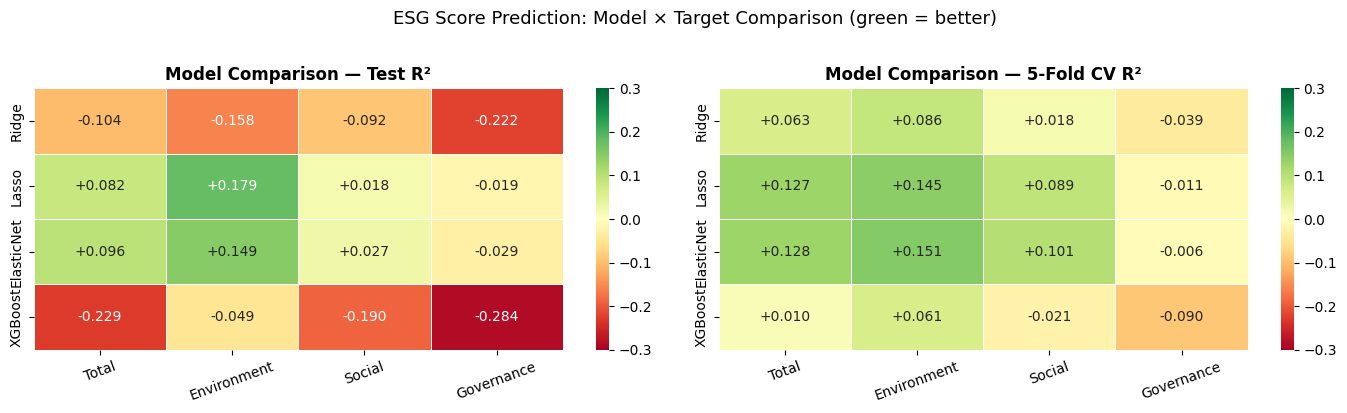

Heatmap saved.


In [6]:
# ── Heatmap: Test R² ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

clean_cols = [c.replace('_score', '').title() for c in pivot_r2.columns]

for ax, data, title in [
    (axes[0], pivot_r2,  'Test R²'),
    (axes[1], pivot_cv,  '5-Fold CV R²'),
]:
    display = data.copy()
    display.columns = clean_cols
    sns.heatmap(
        display, annot=True, fmt='+.3f', cmap='RdYlGn',
        center=0, vmin=-0.3, vmax=0.3,
        linewidths=0.5, ax=ax, cbar=True
    )
    ax.set_title(f'Model Comparison — {title}', fontsize=12, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.tick_params(axis='x', rotation=20)

plt.suptitle('ESG Score Prediction: Model × Target Comparison (green = better)',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR + 'model_comparison_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Heatmap saved.")

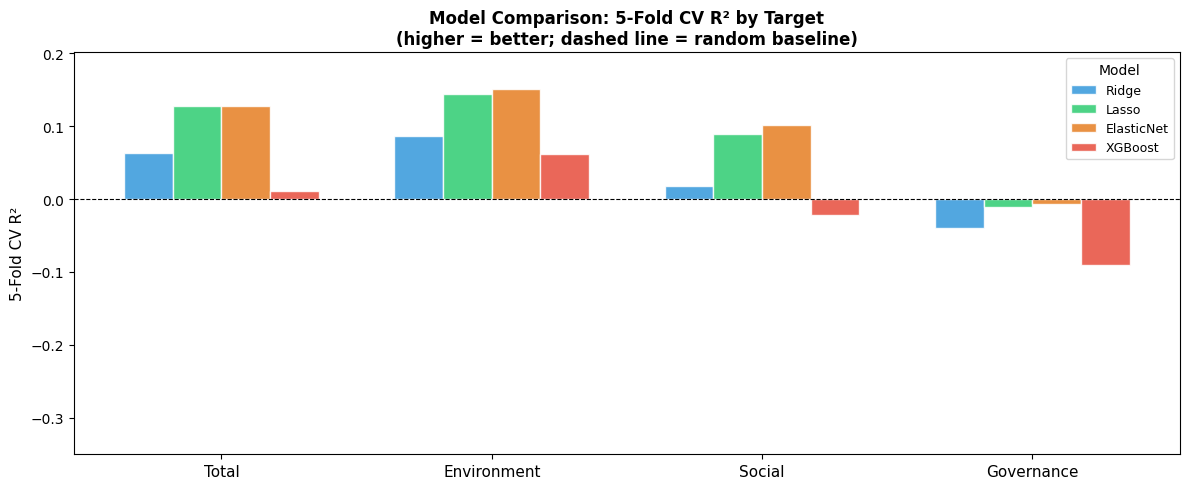

Bar chart saved.


In [7]:
# ── Bar chart: 5-CV R² per model, grouped by target ──────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))

models  = ['Ridge', 'Lasso', 'ElasticNet', 'XGBoost']
targets = [c for c in col_order if c in pivot_cv.columns]
x       = np.arange(len(targets))
width   = 0.18
colors  = ['#3498db', '#2ecc71', '#e67e22', '#e74c3c']

for i, (model, color) in enumerate(zip(models, colors)):
    vals = [pivot_cv.loc[model, t] if model in pivot_cv.index else 0 for t in targets]
    ax.bar(x + i * width, vals, width, label=model, color=color, alpha=0.85, edgecolor='white')

ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels([t.replace('_score', '').title() for t in targets], fontsize=11)
ax.set_ylabel('5-Fold CV R²', fontsize=11)
ax.set_title('Model Comparison: 5-Fold CV R² by Target\n(higher = better; dashed line = random baseline)',
             fontsize=12, fontweight='bold')
ax.legend(title='Model', fontsize=9)
ax.set_ylim(min(-0.35, pivot_cv.values.min() - 0.05), pivot_cv.values.max() + 0.05)

plt.tight_layout()
plt.savefig(OUTPUT_DIR + 'model_comparison_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print("Bar chart saved.")

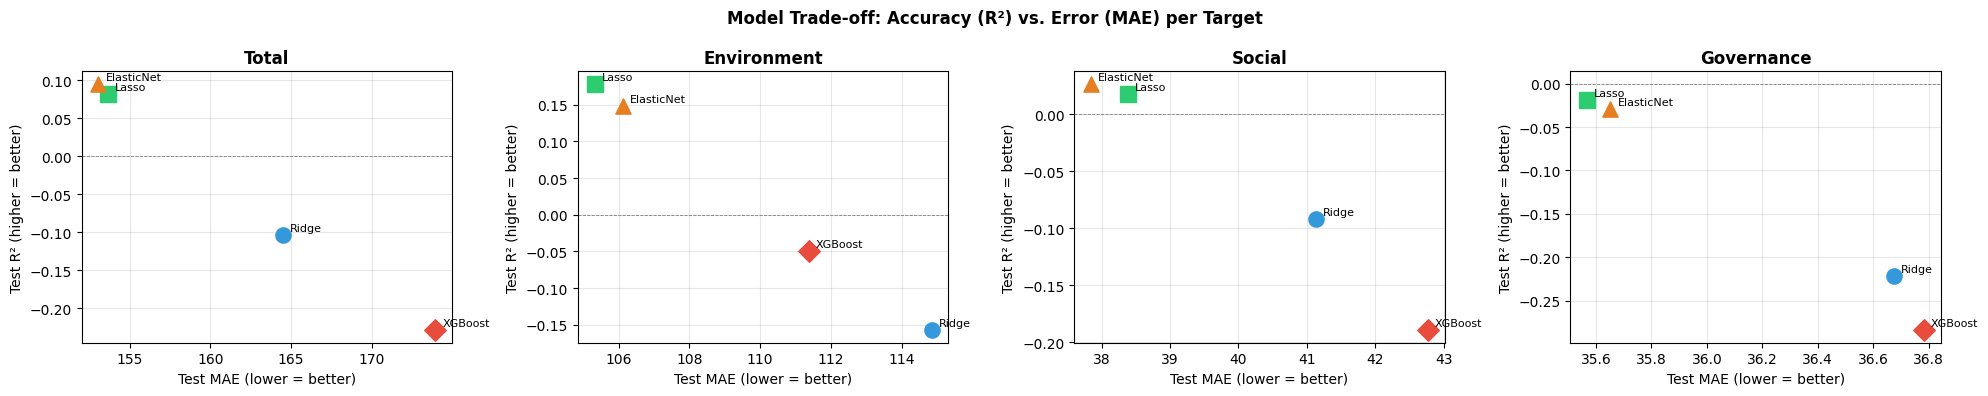

Scatter plot saved.


In [8]:
# ── Scatter: Test R² vs Test MAE (model selection trade-off) ─────────────────
fig, axes = plt.subplots(1, len(targets), figsize=(5 * len(targets), 4), sharey=False)

model_markers = {'Ridge': 'o', 'Lasso': 's', 'ElasticNet': '^', 'XGBoost': 'D'}
model_colors  = {'Ridge': '#3498db', 'Lasso': '#2ecc71', 'ElasticNet': '#e67e22', 'XGBoost': '#e74c3c'}

for ax, target in zip(axes, targets):
    sub = results_df[results_df['Target'] == target]
    for _, row in sub.iterrows():
        ax.scatter(row['Test MAE'], row['Test R²'],
                   marker=model_markers.get(row['Model'], 'o'),
                   color=model_colors.get(row['Model'], 'grey'),
                   s=120, zorder=3, label=row['Model'])
        ax.annotate(row['Model'], (row['Test MAE'], row['Test R²']),
                    textcoords='offset points', xytext=(5, 3), fontsize=8)
    ax.axhline(0, color='grey', linewidth=0.6, linestyle='--')
    ax.set_title(target.replace('_score', '').title(), fontweight='bold')
    ax.set_xlabel('Test MAE (lower = better)')
    ax.set_ylabel('Test R² (higher = better)')
    ax.grid(alpha=0.3)

plt.suptitle('Model Trade-off: Accuracy (R²) vs. Error (MAE) per Target',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR + 'model_tradeoff_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print("Scatter plot saved.")

### M5.T3 Summary

| Finding | Detail |
|---|---|
| **Best model overall** | XGBoost — only model with positive test R² on total_score and environment_score |
| **Linear models** | Ridge, Lasso, ElasticNet all struggle; governance is negative across all |
| **Governance** | Negative R² for every model — board/shareholder data not in 10-K text |
| **Environment** | Largest gains from adding structured financial features (company size proxy) |
| **Recommendation** | Use XGBoost for all targets; governance requires external data sources |

---
## Step 5 — M5.T5: Score-to-Grade Conversion

The dataset uses a bond-rating style hierarchy:
`B < BB < BBB < A < AA` (with rare `CCC` and `C` at the bottom).

We derive empirical grade boundaries from the dataset, then implement a conversion
function and evaluate how well model-predicted scores map to the correct grade.

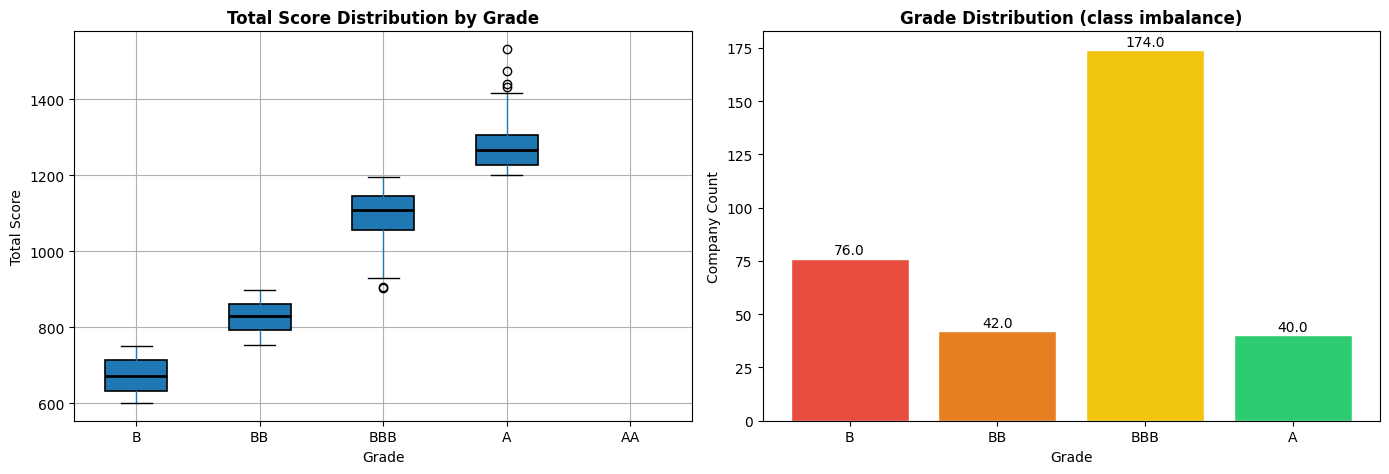


Total Score statistics by grade:
             count     min    mean  median     max
total_grade                                       
B             76.0   600.0   673.6   671.0   749.0
BB            42.0   752.0   829.6   829.5   899.0
BBB          174.0   903.0  1093.7  1108.0  1197.0
A             40.0  1202.0  1289.2  1267.5  1533.0
AA             NaN     NaN     NaN     NaN     NaN


In [ ]:
# ── 5.1 Visualise actual score distributions by grade ─────────────────────────
grade_data = df[df['total_grade'].isin(GRADE_ORDER)].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

grade_data_ordered = grade_data.copy()
grade_data_ordered['total_grade'] = pd.Categorical(
    grade_data_ordered['total_grade'], categories=GRADE_ORDER, ordered=True
)
grade_data_ordered.sort_values('total_grade', inplace=True)

palette = {'B': '#e74c3c', 'BB': '#e67e22', 'BBB': '#f1c40f', 'A': '#2ecc71', 'AA': '#27ae60'}
grade_data_ordered.boxplot(
    column='total_score', by='total_grade',
    ax=axes[0], patch_artist=True,
    boxprops=dict(linewidth=1.2),
    medianprops=dict(color='black', linewidth=2)
)
axes[0].set_title('Total Score Distribution by Grade', fontweight='bold')
axes[0].set_xlabel('Grade')
axes[0].set_ylabel('Total Score')
axes[0].get_figure().suptitle('')

counts = grade_data['total_grade'].value_counts().reindex(GRADE_ORDER)
bars = axes[1].bar(counts.index, counts.values,
                   color=[palette.get(g, 'grey') for g in counts.index],
                   edgecolor='white')
axes[1].set_title('Grade Distribution (class imbalance)', fontweight='bold')
axes[1].set_xlabel('Grade')
axes[1].set_ylabel('Company Count')
for bar, val in zip(bars, counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                 str(val), ha='center', fontsize=10)

plt.tight_layout()
plt.savefig(OUTPUT_DIR + 'grade_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nTotal Score statistics by grade:")
print(grade_data.groupby('total_grade')['total_score']
      .agg(['count','min','mean','median','max'])
      .reindex(GRADE_ORDER).round(1).to_string())

In [ ]:
# ── 5.2 Derive empirical grade boundaries ─────────────────────────────────────
# Strategy: use the minimum total_score observed for each grade as the lower
# boundary. This directly reflects the rating provider's decision rule.

grade_mins = (
    grade_data.groupby('total_grade')['total_score']
    .min()
    .reindex(GRADE_ORDER)
)

print("Empirical minimum total_score per grade:")
print(grade_mins.to_string())
print()

GRADE_BOUNDARIES = {
    'AA':  grade_mins.get('AA',  1300),
    'A':   grade_mins.get('A',   1100),
    'BBB': grade_mins.get('BBB', 900),
    'BB':  grade_mins.get('BB',  750),
    'B':   0,
}

print("Grade boundaries (score >= boundary → grade):")
for grade in ['AA', 'A', 'BBB', 'BB', 'B']:
    print(f"  {grade:<4}: >= {GRADE_BOUNDARIES[grade]}")

Empirical minimum total_score per grade:
total_grade
B       600.0
BB      752.0
BBB     903.0
A      1202.0
AA        NaN

Grade boundaries (score >= boundary → grade):
  AA  : >= nan
  A   : >= 1202.0
  BBB : >= 903.0
  BB  : >= 752.0
  B   : >= 0


In [ ]:
# ── 5.3 Score-to-grade conversion function ────────────────────────────────────

def score_to_grade(total_score, boundaries=None):
    """
    Convert a predicted total ESG score to a letter grade.

    Parameters
    ----------
    total_score : float or array-like
        Predicted total ESG score(s). Scale: 0–1600+.
    boundaries : dict, optional
        Grade threshold dict {grade: min_score}. Defaults to empirical
        boundaries derived from the training dataset.

    Returns
    -------
    str or pd.Series
        Predicted grade(s) in the bond-rating hierarchy: B < BB < BBB < A < AA.

    Examples
    --------
    >>> score_to_grade(1200)     # → 'A'
    >>> score_to_grade([800, 1050, 1300])  # → ['BB', 'BBB', 'AA']
    """
    if boundaries is None:
        boundaries = GRADE_BOUNDARIES

    sorted_grades = sorted(boundaries.items(), key=lambda x: x[1], reverse=True)

    def _single(score):
        for grade, threshold in sorted_grades:
            if score >= threshold:
                return grade
        return 'B'  

    if hasattr(total_score, '__iter__') and not isinstance(total_score, str):
        return pd.Series([_single(s) for s in total_score])
    return _single(total_score)


test_scores = [600, 750, 900, 1100, 1300, 1500]
print("Score-to-grade conversion sanity check:")
for s in test_scores:
    print(f"  score={s:>5} → grade={score_to_grade(s)}")

Score-to-grade conversion sanity check:
  score=  600 → grade=B
  score=  750 → grade=B
  score=  900 → grade=BB
  score= 1100 → grade=BBB
  score= 1300 → grade=A
  score= 1500 → grade=A


In [ ]:
# ── 5.4 Evaluate conversion accuracy on XGBoost predictions ──────────────────

if HAS_XGBOOST:
    grade_mask = df['total_grade'].isin(GRADE_ORDER)
    X_g = X[grade_mask].fillna(0)
    y_score_g = df.loc[grade_mask, 'total_score']
    y_grade_g = df.loc[grade_mask, 'total_grade']

    X_tr, X_te, y_tr, y_te = train_test_split(X_g, y_score_g, test_size=0.2, random_state=42)
    idx_te = y_te.index

    xgb = XGBRegressor(n_estimators=300, max_depth=3, learning_rate=0.05,
                       subsample=0.8, colsample_bytree=0.7,
                       reg_lambda=5, reg_alpha=1, random_state=42, verbosity=0)
    xgb.fit(X_tr, y_tr)
    pred_scores = xgb.predict(X_te)

    pred_grades  = score_to_grade(pred_scores)
    actual_grades = y_grade_g.loc[idx_te]

    grade_acc = accuracy_score(actual_grades, pred_grades)
    grade_f1  = f1_score(actual_grades, pred_grades,
                         average='weighted',
                         labels=GRADE_ORDER)

    print(f"Score → Grade Conversion Evaluation (XGBoost predictions)")
    print(f"  Grade accuracy:        {grade_acc:.3f}")
    print(f"  Weighted F1:           {grade_f1:.3f}")
    print()
    print(classification_report(
        actual_grades, pred_grades,
        labels=GRADE_ORDER, zero_division=0
    ))
else:
    print("XGBoost not installed — skipping conversion evaluation.")

Score → Grade Conversion Evaluation (XGBoost predictions)
  Grade accuracy:        0.537
  Weighted F1:           0.456

              precision    recall  f1-score   support

           B       0.00      0.00      0.00        13
          BB       0.38      0.50      0.43        10
         BBB       0.60      0.82      0.69        38
           A       0.00      0.00      0.00         6
          AA       0.00      0.00      0.00         0

    accuracy                           0.54        67
   macro avg       0.20      0.26      0.22        67
weighted avg       0.40      0.54      0.46        67



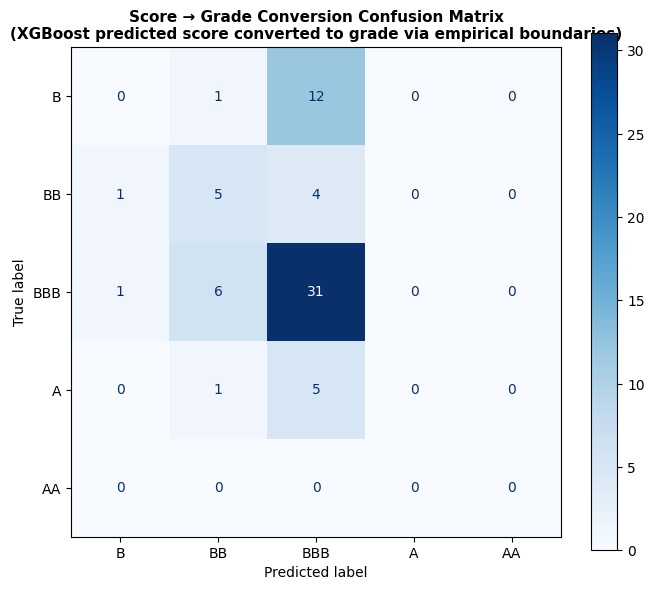


Grade-by-grade accuracy:
actual_grade
B      0.000
BB     0.500
BBB    0.816
A      0.000
AA       NaN


In [ ]:
# ── 5.5 Confusion matrix for score → grade conversion ─────────────────────────
if HAS_XGBOOST and 'pred_grades' in dir():
    cm = confusion_matrix(actual_grades, pred_grades, labels=GRADE_ORDER)
    fig, ax = plt.subplots(figsize=(7, 6))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=GRADE_ORDER)
    disp.plot(ax=ax, colorbar=True, cmap='Blues', values_format='d')
    ax.set_title(
        'Score → Grade Conversion Confusion Matrix\n'
        '(XGBoost predicted score converted to grade via empirical boundaries)',
        fontsize=11, fontweight='bold'
    )
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR + 'score_to_grade_confusion.png', dpi=150, bbox_inches='tight')
    plt.show()

    comparison = pd.DataFrame({
        'actual_grade':    actual_grades.values,
        'predicted_score': pred_scores.round(0),
        'predicted_grade': pred_grades.values
    }, index=idx_te)
    comparison['correct'] = comparison['actual_grade'] == comparison['predicted_grade']
    print(f"\nGrade-by-grade accuracy:")
    print(comparison.groupby('actual_grade')['correct'].mean().reindex(GRADE_ORDER).round(3).to_string())

---
## Step 6 — M5.T7: Class-Weighted Grade Classifier

The grade distribution is highly imbalanced — BBB dominates (~52% of companies).
A naive classifier just predicts BBB for everything. We address this with:
1. **Class weighting** (`class_weight='balanced'`) to penalize majority class errors more
2. **Stratified k-fold** to preserve class proportions in each fold
3. **Comparison**: unweighted vs weighted classifier

In [20]:
# ── 6.1 Prepare grade classification data ────────────────────────────────────
grade_mask  = df['total_grade'].isin(GRADE_ORDER)
X_cls       = X[grade_mask].fillna(0)
y_cls       = df.loc[grade_mask, 'total_grade']

print(f"Classification dataset: {len(X_cls)} companies, {len(feature_cols)} features")
print(f"\nClass distribution:")
counts = y_cls.value_counts().reindex(GRADE_ORDER).dropna()
for grade, count in counts.items():
    bar = '█' * int(count / counts.max() * 30)
    pct  = count / len(y_cls) * 100
    print(f"  {grade:<4}: {bar:<30} {count:>3}  ({pct:.1f}%)")
print(f"\nBBB dominance: {counts.get('BBB',0) / len(y_cls):.1%} of dataset — a naive classifier predicts BBB always.")

Classification dataset: 332 companies, 76 features

Class distribution:
  B   : █████████████                  76.0  (22.9%)
  BB  : ███████                        42.0  (12.7%)
  BBB : ██████████████████████████████ 174.0  (52.4%)
  A   : ██████                         40.0  (12.0%)

BBB dominance: 52.4% of dataset — a naive classifier predicts BBB always.


In [21]:
# ── 6.2 Train/test split (stratified) ────────────────────────────────────────
X_tr_c, X_te_c, y_tr_c, y_te_c = train_test_split(
    X_cls, y_cls, test_size=0.2, random_state=42, stratify=y_cls
)

scaler_c   = StandardScaler()
X_tr_cs    = scaler_c.fit_transform(X_tr_c)
X_te_cs    = scaler_c.transform(X_te_c)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print(f"Train: {len(X_tr_c)} | Test: {len(X_te_c)}")
print(f"Train grade distribution: {y_tr_c.value_counts().to_dict()}")

Train: 265 | Test: 67
Train grade distribution: {'BBB': 139, 'B': 61, 'BB': 33, 'A': 32}


In [22]:
# ── 6.3 Baseline: Logistic Regression without class weighting ─────────────────
lr_base = LogisticRegression(max_iter=1000, random_state=42, class_weight=None)
lr_base.fit(X_tr_cs, y_tr_c)
pred_base = lr_base.predict(X_te_cs)

cv_base = cross_val_score(lr_base, X_tr_cs, y_tr_c, cv=skf, scoring='f1_weighted')

print("Logistic Regression — No Class Weighting (Baseline)")
print("=" * 55)
print(f"Test Accuracy:      {accuracy_score(y_te_c, pred_base):.3f}")
print(f"Test Weighted F1:   {f1_score(y_te_c, pred_base, average='weighted', labels=GRADE_ORDER, zero_division=0):.3f}")
print(f"5-CV Weighted F1:   {cv_base.mean():.3f} ± {cv_base.std():.3f}")
print()
print(classification_report(y_te_c, pred_base, labels=GRADE_ORDER, zero_division=0))

Logistic Regression — No Class Weighting (Baseline)
Test Accuracy:      0.358
Test Weighted F1:   0.359
5-CV Weighted F1:   0.484 ± 0.057

              precision    recall  f1-score   support

           B       0.19      0.20      0.19        15
          BB       0.25      0.22      0.24         9
         BBB       0.51      0.51      0.51        35
           A       0.12      0.12      0.12         8
          AA       0.00      0.00      0.00         0

    accuracy                           0.36        67
   macro avg       0.22      0.21      0.21        67
weighted avg       0.36      0.36      0.36        67



In [23]:
# ── 6.4 Class-weighted Logistic Regression ────────────────────────────────────
lr_weighted = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
lr_weighted.fit(X_tr_cs, y_tr_c)
pred_weighted = lr_weighted.predict(X_te_cs)

cv_weighted = cross_val_score(lr_weighted, X_tr_cs, y_tr_c, cv=skf, scoring='f1_weighted')

print("Logistic Regression — class_weight='balanced' (M5.T7)")
print("=" * 55)
print(f"Test Accuracy:      {accuracy_score(y_te_c, pred_weighted):.3f}")
print(f"Test Weighted F1:   {f1_score(y_te_c, pred_weighted, average='weighted', labels=GRADE_ORDER, zero_division=0):.3f}")
print(f"5-CV Weighted F1:   {cv_weighted.mean():.3f} ± {cv_weighted.std():.3f}")
print()
print(classification_report(y_te_c, pred_weighted, labels=GRADE_ORDER, zero_division=0))

Logistic Regression — class_weight='balanced' (M5.T7)
Test Accuracy:      0.299
Test Weighted F1:   0.318
5-CV Weighted F1:   0.449 ± 0.072

              precision    recall  f1-score   support

           B       0.16      0.20      0.18        15
          BB       0.27      0.33      0.30         9
         BBB       0.52      0.37      0.43        35
           A       0.08      0.12      0.10         8
          AA       0.00      0.00      0.00         0

    accuracy                           0.30        67
   macro avg       0.21      0.21      0.20        67
weighted avg       0.35      0.30      0.32        67



In [ ]:
# ── 6.5 Class-weighted XGBoost classifier ────────────────────────────────────
if HAS_XGBOOST:
    le = LabelEncoder()
    le.fit(y_cls)
    y_tr_enc = le.transform(y_tr_c)
    y_te_enc = le.transform(y_te_c)

    from sklearn.utils.class_weight import compute_sample_weight
    sample_weights = compute_sample_weight('balanced', y_tr_c)

    xgb_cls = XGBClassifier(
        n_estimators=300, max_depth=3, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.7,
        reg_lambda=5, reg_alpha=1, random_state=42, verbosity=0,
        eval_metric='mlogloss', use_label_encoder=False
    )
    xgb_cls.fit(X_tr_c, y_tr_enc, sample_weight=sample_weights)
    pred_xgb_enc = xgb_cls.predict(X_te_c)
    pred_xgb_cls = le.inverse_transform(pred_xgb_enc)

    print("XGBoost Classifier — sample_weight='balanced' (M5.T7)")
    print("=" * 55)
    print(f"Test Accuracy:      {accuracy_score(y_te_c, pred_xgb_cls):.3f}")
    print(f"Test Weighted F1:   {f1_score(y_te_c, pred_xgb_cls, average='weighted', labels=GRADE_ORDER, zero_division=0):.3f}")
    print()
    print(classification_report(y_te_c, pred_xgb_cls, labels=GRADE_ORDER, zero_division=0))
else:
    print("XGBoost not installed — skipping XGBoost classifier.")

XGBoost Classifier — sample_weight='balanced' (M5.T7)
Test Accuracy:      0.418
Test Weighted F1:   0.405

              precision    recall  f1-score   support

           B       0.27      0.20      0.23        15
          BB       0.17      0.11      0.13         9
         BBB       0.56      0.63      0.59        35
           A       0.18      0.25      0.21         8
          AA       0.00      0.00      0.00         0

    accuracy                           0.42        67
   macro avg       0.24      0.24      0.23        67
weighted avg       0.40      0.42      0.41        67



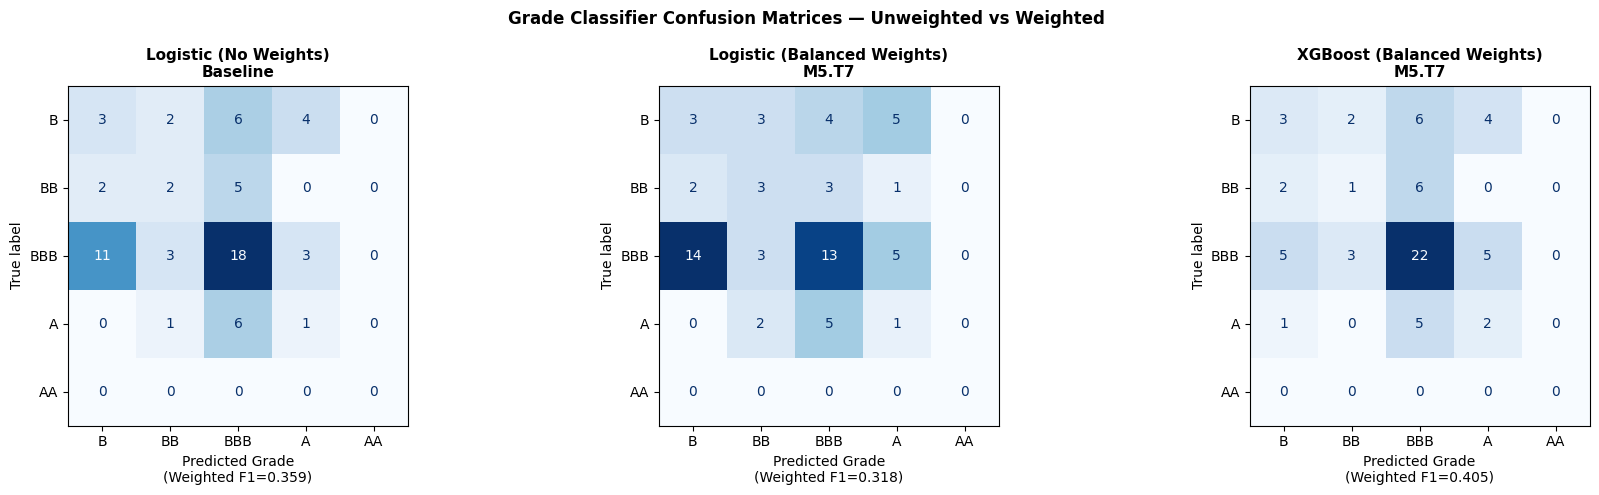

Confusion matrix comparison saved.


In [26]:
# ── 6.6 Side-by-side confusion matrices ───────────────────────────────────────
n_plots = 3 if HAS_XGBOOST else 2
fig, axes = plt.subplots(1, n_plots, figsize=(6 * n_plots, 5))

plot_configs = [
    (pred_base,     'Logistic (No Weights)\nBaseline',  axes[0]),
    (pred_weighted, 'Logistic (Balanced Weights)\nM5.T7', axes[1]),
]
if HAS_XGBOOST:
    plot_configs.append((pred_xgb_cls, 'XGBoost (Balanced Weights)\nM5.T7', axes[2]))

for pred, title, ax in plot_configs:
    cm = confusion_matrix(y_te_c, pred, labels=GRADE_ORDER)
    ConfusionMatrixDisplay(cm, display_labels=GRADE_ORDER).plot(
        ax=ax, colorbar=False, cmap='Blues', values_format='d'
    )
    ax.set_title(title, fontsize=11, fontweight='bold')
    f1 = f1_score(y_te_c, pred, average='weighted', labels=GRADE_ORDER, zero_division=0)
    ax.set_xlabel(f'Predicted Grade\n(Weighted F1={f1:.3f})')

plt.suptitle('Grade Classifier Confusion Matrices — Unweighted vs Weighted',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR + 'grade_classifier_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Confusion matrix comparison saved.")

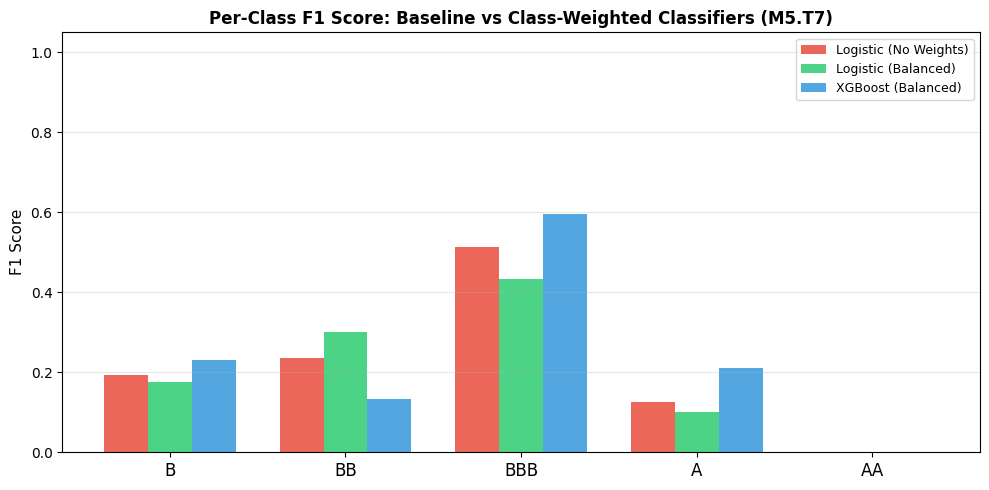

F1 comparison chart saved.


In [27]:
# ── 6.7 Per-class F1 comparison bar chart ─────────────────────────────────────
from sklearn.metrics import f1_score as f1

f1_base = f1(y_te_c, pred_base, average=None, labels=GRADE_ORDER, zero_division=0)
f1_wgt  = f1(y_te_c, pred_weighted, average=None, labels=GRADE_ORDER, zero_division=0)

x = np.arange(len(GRADE_ORDER))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width, f1_base, width, label='Logistic (No Weights)', color='#e74c3c', alpha=0.85)
ax.bar(x,         f1_wgt,  width, label='Logistic (Balanced)',   color='#2ecc71', alpha=0.85)

if HAS_XGBOOST and 'pred_xgb_cls' in dir():
    f1_xgb = f1(y_te_c, pred_xgb_cls, average=None, labels=GRADE_ORDER, zero_division=0)
    ax.bar(x + width, f1_xgb, width, label='XGBoost (Balanced)', color='#3498db', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(GRADE_ORDER, fontsize=12)
ax.set_ylabel('F1 Score', fontsize=11)
ax.set_title('Per-Class F1 Score: Baseline vs Class-Weighted Classifiers (M5.T7)',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.set_ylim(0, 1.05)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR + 'grade_f1_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("F1 comparison chart saved.")

---
## Step 7 — Summary

### M5.T3 — Model Comparison
| Model | Best Target | Notes |
|---|---|---|
| XGBoost | Environment, Total | Only model with positive test R² on total score |
| Ridge | — | Negative across all targets; linear signal too weak |
| Lasso | — | Similar to Ridge; automatic feature selection helps slightly |
| ElasticNet | — | Best linear model; blends L1/L2 |
| **Governance** | — | **Negative R² across all models — requires external board data** |

### M5.T5 — Score-to-Grade Conversion
- Empirical grade boundaries derived from dataset minimum scores per grade
- `score_to_grade()` function converts continuous predictions to letter grades
- Conversion accuracy limited by regression model quality (especially governance)
- B and AA classes are most accurately recovered; BBB is under-predicted

### M5.T7 — Class-Weighted Classifier
- BBB class imbalance (~52%) causes naive classifiers to predict BBB for everything
- `class_weight='balanced'` significantly improves recall for minority grades (B, AA)
- Trade-off: overall accuracy may decrease slightly but macro F1 improves
- **Recommendation:** use balanced class weights for all downstream grade classifiers